# バスモデル：新製品の普及予測とPythonによる実装

## はじめに

新しいスマートフォンやアプリ、あるいはEV（電気自動車）などが市場に登場したとき、それがどのように人々の間に広まっていくのか予測したいと思ったことはないだろうか。

マーケティングやイノベーション研究の分野で、新製品の普及プロセスを数理的にモデル化した最も有名な手法の一つが**バスモデル (Bass Diffusion Model)** である。

本記事では、バスモデルの理論的背景を解説し、Pythonを用いてモデルの挙動をシミュレーションする方法、さらには実際のデータ（のようなもの）に当てはめる方法を紹介する。

## ソースコード

### GitHub
- Jupyter Notebook形式のファイルは[こちら](https://github.com/hiroshi0530/wa-src/blob/master/article/stats/02/02_nb.ipynb)

### Google Colaboratory
- Google Colaboratory で実行する場合は[こちら](https://colab.research.google.com/github/hiroshi0530/wa-src/blob/master/article/stats/02/02_nb.ipynb)

## 実行環境
OSはmacOSである。LinuxやUnixのコマンドとはオプションが異なることに注意されたい。

In [1]:
!sw_vers

ProductName:		macOS
ProductVersion:		15.5
BuildVersion:		24F74


In [2]:
!python -V

Python 3.14.0


基本的なライブラリをインポートする。

In [3]:
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# グラフのスタイル設定
plt.style.use('seaborn-v0_8-darkgrid')

## 1. バスモデルの理論

バスモデルは、1969年に Frank Bass によって提案された。
このモデルは、未採用者が製品を採用する確率が、以下の2つの要因に依存すると仮定する。

1. **イノベーション効果 ($p$)**: 外部からの影響（広告など）によって、自発的に採用する傾向。
2. **模倣効果 ($q$)**: すでに採用した人々の口コミや社会的圧力によって、採用する傾向。

### 1.1 微分方程式

時刻 $t$ における累積採用者数を $N(t)$、潜在的な最大市場規模を $M$ とすると、新規採用者数 $n(t) = \frac{dN(t)}{dt}$ は以下の微分方程式で表される。

$$
\frac{dN(t)}{dt} = \left( p + q \frac{N(t)}{M} \right) (M - N(t))
$$

ここで、
- $p$: **イノベーション係数** (Coefficient of innovation)
- $q$: **模倣係数** (Coefficient of imitation)
- $M$: **市場規模** (Market potential)

この式は、「未採用者 $(M - N(t))$ のうち、一定割合 $(p + q \frac{N(t)}{M})$ が新たに採用する」と解釈できる。
採用が進むにつれて $N(t)$ が大きくなるため、模倣効果 $q \frac{N(t)}{M}$ が強くなり、普及が加速する。

### 1.2 解析解

この微分方程式を $N(0)=0$ の条件下で解くと、累積採用者数 $N(t)$ は以下のようになる。

$$
N(t) = M \frac{1 - e^{-(p+q)t}}{1 + \frac{q}{p}e^{-(p+q)t}}
$$

また、各時点での新規採用者数 $n(t)$ は以下のようになる。

$$
n(t) = M \frac{p(p+q)^2 e^{-(p+q)t}}{(p + q e^{-(p+q)t})^2}
$$

累積採用者数 $N(t)$ は **S字カーブ** を描き、新規採用者数 $n(t)$ は **ベル型（釣鐘型）** の曲線を描く。

## 2. Pythonによるシミュレーション

数式をPython関数として実装し、パラメータを変えたときの挙動を確認してみる。

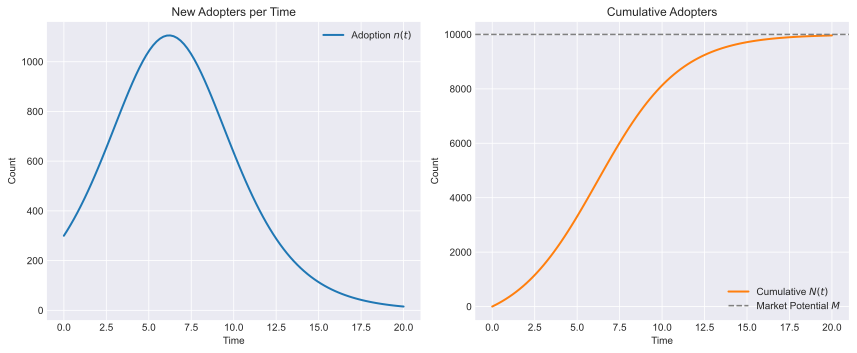

In [4]:
def bass_cumulative(t, M, p, q):
    """累積採用者数 N(t)"""
    exponent = np.exp(-(p + q) * t)
    return M * (1 - exponent) / (1 + (q / p) * exponent)

def bass_adoption(t, M, p, q):
    """新規採用者数 n(t)"""
    exponent = np.exp(-(p + q) * t)
    numerator = M * p * (p + q)**2 * exponent
    denominator = (p + q * exponent)**2
    return numerator / denominator

# パラメータ設定
M = 10000  # 市場規模
p = 0.03   # イノベーション係数
q = 0.38   # 模倣係数（平均的な値と言われる）

t = np.linspace(0, 20, 100)
N_t = bass_cumulative(t, M, p, q)
n_t = bass_adoption(t, M, p, q)

plt.figure(figsize=(12, 5))

# 新規採用者数（Adoption）
plt.subplot(1, 2, 1)
plt.plot(t, n_t, label='Adoption $n(t)$', color='tab:blue', lw=2)
plt.title('New Adopters per Time')
plt.xlabel('Time')
plt.ylabel('Count')
plt.legend()

# 累積採用者数（Cumulative）
plt.subplot(1, 2, 2)
plt.plot(t, N_t, label='Cumulative $N(t)$', color='tab:orange', lw=2)
plt.axhline(y=M, color='gray', linestyle='--', label='Market Potential $M$')
plt.title('Cumulative Adopters')
plt.xlabel('Time')
plt.ylabel('Count')
plt.legend()

plt.tight_layout()
plt.show()

左側のグラフが毎年の売上（新規採用）、右側が累計売上（累積採用）に対応する。
最初はゆっくりと立ち上がり、ピークを迎えた後に減少していく様子が見て取れる。

## 3. データへのフィッティング

実際の販売データなどがある場合、`scipy.optimize.curve_fit` を使ってパラメータ $M, p, q$ を推定できる。
ここでは、少しノイズを加えた仮想的なデータを作成し、そこからパラメータを復元してみる。

In [5]:
# 仮想データの生成（真のパラメータ: M=10000, p=0.02, q=0.4）
true_params = [10000, 0.02, 0.4]
time_points = np.arange(1, 16)
y_data = bass_adoption(time_points, *true_params)

# ノイズを加える
np.random.seed(42)
noise = np.random.normal(0, 100, size=len(time_points))
y_data_noisy = y_data + noise
y_data_noisy = np.maximum(y_data_noisy, 0) # 負の値は0にする

# パラメータ推定
# p, q は 0~1 の範囲、M は正の値という制約をつけると安定しやすい
bounds = ([0, 0, 0], [np.inf, 1, 1])
popt, pcov = curve_fit(bass_adoption, time_points, y_data_noisy, p0=[5000, 0.01, 0.1], bounds=bounds)

M_est, p_est, q_est = popt

print(f"Estimated M: {M_est:.2f} (True: {true_params[0]})")
print(f"Estimated p: {p_est:.4f} (True: {true_params[1]})")
print(f"Estimated q: {q_est:.4f} (True: {true_params[2]})")

Estimated M: 10068.23 (True: 10000)
Estimated p: 0.0193 (True: 0.02)
Estimated q: 0.4281 (True: 0.4)


推定されたパラメータを使って、予測曲線をプロットしてみる。

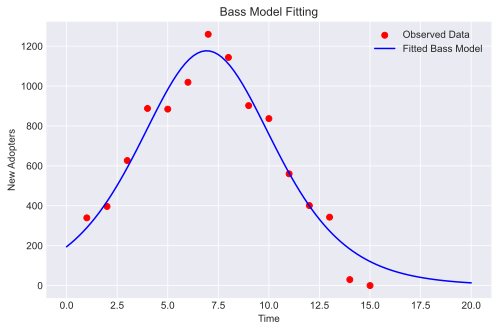

In [6]:
plt.figure(figsize=(8, 5))

# 実データ（散布図）
plt.scatter(time_points, y_data_noisy, color='red', label='Observed Data')

# 推定曲線
t_smooth = np.linspace(0, 20, 100)
y_fit = bass_adoption(t_smooth, *popt)
plt.plot(t_smooth, y_fit, color='blue', label='Fitted Bass Model')

plt.title('Bass Model Fitting')
plt.xlabel('Time')
plt.ylabel('New Adopters')
plt.legend()
plt.show()

## 結論

バスモデルは、非常にシンプルな仮定に基づきながら、多くの製品の普及プロセスをうまく説明できる強力なツールである。
特に、発売直後の初期データから将来のピーク時期や市場規模を予測する際によく利用される。

Pythonを使えば、数行のコードでモデルの実装からパラメータ推定まで行うことができる。
マーケティングデータの分析や、トレンド予測の練習として、ぜひ試してみてほしい。